# Nghiên cứu thực nghiệm: Phân tích Khám phá Dữ liệu (EDA) Stock 1-phút

Notebook này được thiết kế để làm sạch, kiểm định tính hợp lệ, chuẩn hóa và trích xuất đặc trưng thời gian cho ma trận 5 chiều (**OHLCV**) trước khi đưa vào mô hình PyTorch (đặc biệt là mô hình **CALF** dựa trên kiến trúc chuyển giao tri thức đa phương thức).

## Mục tiêu kiểm định & Logic triển khai:
1. **Kiểm tra tính liên tục (Continuity Check)**: Tính toán khoảng cách thời gian $\Delta t$ giữa các timestamps. Thiết lập bộ lọc để bỏ qua các khoảng nghỉ tự nhiên của thị trường Việt Nam (nghỉ trưa, qua đêm, cuối tuần) và phát hiện các đứt gãy dữ liệu thực sự.
2. **Điền khuyết (Forward-Fill Imputation)**: Sử dụng phương pháp điền tiến (Forward-Fill) để xử lý các khoảng đứt gãy, loại bỏ hoàn toàn rò rỉ dữ liệu tương lai (look-ahead bias).
3. **Kiểm định Thang đo (Scaling Check)**: Kiểm chứng phân phối trước và sau khi chuẩn hóa bằng `StandardScaler`, trực quan hóa qua biểu đồ Histogram & KDE.
4. **Phân tích Tương quan Pearson**: Kiểm tra đa cộng tuyến hoàn toàn giữa 5 thuộc tính $O, H, L, C, V$.
5. **Trích xuất đặc trưng thời gian (Time Features)**: Tạo các cột phụ (Day of week, Hour of day, Minute of hour) để làm dữ liệu `x_mark` và `y_mark` cung cấp bối cảnh thời gian cho LLM.
6. **Trực quan hóa Line Charts**: Biểu diễn các biến OHLCV dưới dạng biểu đồ đường để theo dõi biến động, bao gồm biểu đồ tổng hợp 5 biến (sử dụng 2 trục Y song song), phóng to phân đoạn thời gian và vẽ các đồ thị đường riêng biệt cho từng đặc trưng.

## Bước 1: Khởi tạo Thư viện & Thiết lập Cấu hình

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Cấu hình hiển thị đồ họa đẹp mắt
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
custom_palette = sns.color_palette("coolwarm", as_cmap=True)

## Bước 2: Nạp dữ liệu & Tiền xử lý Sơ bộ

Chúng ta sẽ tự động tìm kiếm tệp tin dữ liệu `.csv` trong thư mục dữ liệu `vn_stock`.

In [2]:
# Xác định đường dẫn tuyệt đối tới thư mục dữ liệu
data_dir = r"C:\Users\USER\Desktop\time_series\LLM for timeseries\LLMsForTimeSeries\CALF\dataset\vn_stock"
csv_files = glob.glob(os.path.join(data_dir, "**/*.csv"), recursive=True)

if not csv_files:
    raise FileNotFoundError("Không tìm thấy tệp CSV nào trong thư mục dataset/vn_stock. Vui lòng kiểm tra lại dữ liệu.")

print("Các tệp dữ liệu tìm thấy:")
for f in csv_files:
    print(f" - {f}")

# Chọn tệp dữ liệu đầu tiên để phân tích làm mẫu
target_file = csv_files[0]
print(f"\nĐang nạp tệp: {target_file}")

df = pd.read_csv(target_file)
print(f"Kích thước dữ liệu gốc: {df.shape}")

# Chuyển đổi timestamp sang định dạng DatetimeIndex và sắp xếp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df.head()

Các tệp dữ liệu tìm thấy:
 - C:\Users\USER\Desktop\time_series\LLM for timeseries\LLMsForTimeSeries\CALF\dataset\vn_stock\raw\BTC_USDT_1m.csv

Đang nạp tệp: C:\Users\USER\Desktop\time_series\LLM for timeseries\LLMsForTimeSeries\CALF\dataset\vn_stock\raw\BTC_USDT_1m.csv
Kích thước dữ liệu gốc: (30000, 6)


,timestamp,open,high,low,close,volume
0,2026-05-03 19:32:00,78690.00,78745.39,78689.99,78745.38,6.19421
1,2026-05-03 19:33:00,78745.38,78790.00,78745.38,78778.91,7.30668
2,2026-05-03 19:34:00,78778.92,78853.32,78778.91,78830.54,13.56199
3,2026-05-03 19:35:00,78830.53,78840.00,78825.16,78825.16,2.45859
4,2026-05-03 19:36:00,78825.17,78825.17,78798.07,78798.07,2.77882


## Bước 3: Kiểm tra Tính liên tục & Phát hiện Đứt gãy Dữ liệu

Thị trường chứng khoán Việt Nam (HOSE/HNX) giao dịch theo phiên cố định:
- **Phiên sáng**: 09:00 - 11:30
- **Phiên chiều**: 13:00 - 15:00
- **Ngày giao dịch**: Từ Thứ Hai đến Thứ Sáu (nghỉ Thứ Bảy, Chủ Nhật và ngày lễ).

Đối với tài sản Crypto (ví dụ: BTC/USDT làm mẫu thử), dữ liệu chạy liên tục 24/7. 

Chúng ta sẽ viết logic kiểm định linh hoạt để phát hiện các khoảng đứt gãy thực sự.

In [3]:
def analyze_continuity(df, expected_delta_min=1, asset_type='vn_stock'):
    """
    Kiểm tra tính liên tục của thời gian và phát hiện điểm đứt gãy thực sự
    """
    temp_df = df.copy()
    temp_df['time_diff'] = temp_df['timestamp'].diff()
    
    # Lọc ra các điểm có khoảng cách lớn hơn expected_delta_min phút
    gaps = temp_df[temp_df['time_diff'] > pd.Timedelta(minutes=expected_delta_min)].copy()
    
    if gaps.empty:
        print("Dữ liệu liên tục tuyệt đối, không phát hiện khoảng ngắt quãng nào.")
        return temp_df, pd.DataFrame()

    gaps['prev_timestamp'] = gaps['timestamp'] - gaps['time_diff']
    gaps['gap_duration_minutes'] = gaps['time_diff'].dt.total_seconds() / 60
    
    # Nếu là chứng khoán Việt Nam, ta lọc bỏ giờ nghỉ và cuối tuần
    if asset_type == 'vn_stock':
        real_gaps = []
        for idx, row in gaps.iterrows():
            prev_t = row['prev_timestamp']
            curr_t = row['timestamp']
            
            # Nếu khoảng trống xảy ra qua đêm hoặc cuối tuần hoặc nghỉ trưa
            # Nghỉ trưa: từ 11:30 đến 13:00 cùng ngày
            is_lunch_break = (prev_t.date() == curr_t.date()) and (prev_t.hour == 11 and prev_t.minute >= 30) and (curr_t.hour == 13 and curr_t.minute <= 0)
            # Qua đêm: từ 15:00 hôm trước đến 09:00 hôm sau
            is_overnight = (curr_t - prev_t <= pd.Timedelta(hours=19)) and (prev_t.hour >= 14 and curr_t.hour <= 9)
            # Cuối tuần: từ chiều Thứ Sáu đến sáng Thứ Hai
            is_weekend = (prev_t.dayofweek == 4 and curr_t.dayofweek == 0) and (curr_t - prev_t <= pd.Timedelta(days=3.5))
            
            if not (is_lunch_break or is_overnight or is_weekend):
                real_gaps.append(row)
                
        real_gaps_df = pd.DataFrame(real_gaps)
    else:
        # Với Crypto hoặc dữ liệu 24/7, mọi khoảng trống > 1 phút đều là đứt gãy dữ liệu
        real_gaps_df = gaps
        
    print(f"Tổng số khoảng trống thời gian thô phát hiện: {len(gaps)}")
    if asset_type == 'vn_stock':
        print(f"Tổng số khoảng đứt gãy thực sự ngoài khung giờ nghỉ giao dịch: {len(real_gaps_df)}")
    
    if not real_gaps_df.empty:
        print("\nMột số điểm đứt gãy tiêu biểu:")
        print(real_gaps_df[['prev_timestamp', 'timestamp', 'gap_duration_minutes']].head(10).to_string(index=False))
        
    return temp_df, real_gaps_df

# Kiểm thử: Tự động phát hiện kiểu tài sản dựa trên tên tệp tin để cấu hình chính xác
is_crypto_demo = "BTC" in target_file or "USDT" in target_file
asset_type_selected = 'crypto' if is_crypto_demo else 'vn_stock'

print(f"Phân tích dữ liệu theo cấu hình tài sản: {asset_type_selected.upper()}")
_, real_gaps = analyze_continuity(df, expected_delta_min=1, asset_type=asset_type_selected)

Phân tích dữ liệu theo cấu hình tài sản: CRYPTO
Dữ liệu liên tục tuyệt đối, không phát hiện khoảng ngắt quãng nào.


## Bước 4: Điền Khuyết Dữ liệu (Imputation) Tránh Rò Rỉ Tương Lai

Để cấp đầu vào hợp lệ vào PyTorch, ta cần tái cấu trúc chỉ mục dữ liệu sao cho liên tục hoàn toàn trong phiên giao dịch và thực hiện **Forward-Fill (ffill)**.

In [4]:
def impute_missing_data(df, asset_type='vn_stock'):
    """
    Tạo lưới thời gian chuẩn và điền khuyết bằng phương pháp Forward-Fill để loại bỏ rò rỉ dữ liệu
    """
    df_clean = df.copy()
    df_clean = df_clean.set_index('timestamp')
    
    min_time = df_clean.index.min()
    max_time = df_clean.index.max()
    
    # 1. Tạo chuỗi thời gian liên tục 1 phút thô
    full_range = pd.date_range(start=min_time, end=max_time, freq='1min')
    
    if asset_type == 'vn_stock':
        # Lọc lưới thời gian chuẩn theo khung giờ giao dịch chứng khoán Việt Nam
        valid_minutes = []
        for t in full_range:
            # Lọc bỏ cuối tuần
            if t.dayofweek >= 5:
                continue
            
            # Khung giờ sáng: 9:00 - 11:30
            is_morning = (t.hour > 9 or (t.hour == 9 and t.minute >= 0)) and (t.hour < 11 or (t.hour == 11 and t.minute <= 30))
            # Khung giờ chiều: 13:00 - 15:00
            is_afternoon = (t.hour > 13 or (t.hour == 13 and t.minute >= 0)) and (t.hour < 15 or (t.hour == 15 and t.minute <= 0))
            
            if is_morning or is_afternoon:
                valid_minutes.append(t)
        
        target_index = pd.DatetimeIndex(valid_minutes)
    else:
        target_index = full_range
        
    # 2. Reindex lưới thời gian
    df_imputed = df_clean.reindex(target_index)
    nan_count_before = df_imputed.isnull().sum().sum()
    
    # 3. Điền tiến Forward-fill tránh look-ahead bias
    # Sử dụng ffill cho tất cả OHLCV
    df_imputed = df_imputed.ffill()
    
    # Xử lý trường hợp đặc biệt ở đầu tập dữ liệu nếu dòng đầu bị NaN (dùng bfill tối thiểu)
    df_imputed = df_imputed.bfill()
    
    nan_count_after = df_imputed.isnull().sum().sum()
    
    print(f"Kích thước tập dữ liệu sau khi Reindex lưới thời gian liên tục: {df_imputed.shape}")
    print(f"Số lượng giá trị NaN xuất hiện sau Reindex (cần điền): {nan_count_before}")
    print(f"Số lượng giá trị NaN còn lại sau khi áp dụng ffill: {nan_count_after}")
    
    # Khôi phục cột timestamp
    df_imputed = df_imputed.reset_index().rename(columns={'index': 'timestamp'})
    return df_imputed

df_imputed = impute_missing_data(df, asset_type=asset_type_selected)
df_imputed.head()

Kích thước tập dữ liệu sau khi Reindex lưới thời gian liên tục: (30000, 5)
Số lượng giá trị NaN xuất hiện sau Reindex (cần điền): 0
Số lượng giá trị NaN còn lại sau khi áp dụng ffill: 0


,timestamp,open,high,low,close,volume
0,2026-05-03 19:32:00,78690.00,78745.39,78689.99,78745.38,6.19421
1,2026-05-03 19:33:00,78745.38,78790.00,78745.38,78778.91,7.30668
2,2026-05-03 19:34:00,78778.92,78853.32,78778.91,78830.54,13.56199
3,2026-05-03 19:35:00,78830.53,78840.00,78825.16,78825.16,2.45859
4,2026-05-03 19:36:00,78825.17,78825.17,78798.07,78798.07,2.77882


## Bước 5: Kiểm định Thang đo (Scaling Check)

Đảm bảo chia Train/Test theo thời gian thực tế để `.fit()` chỉ diễn ra trên tập Train, tránh rò rỉ phân phối dữ liệu (Data Leakage) sang tập Test.

Quy mô dữ liệu huấn luyện (Train): (24000, 6)
Quy mô dữ liệu kiểm thử (Test): (6000, 6)


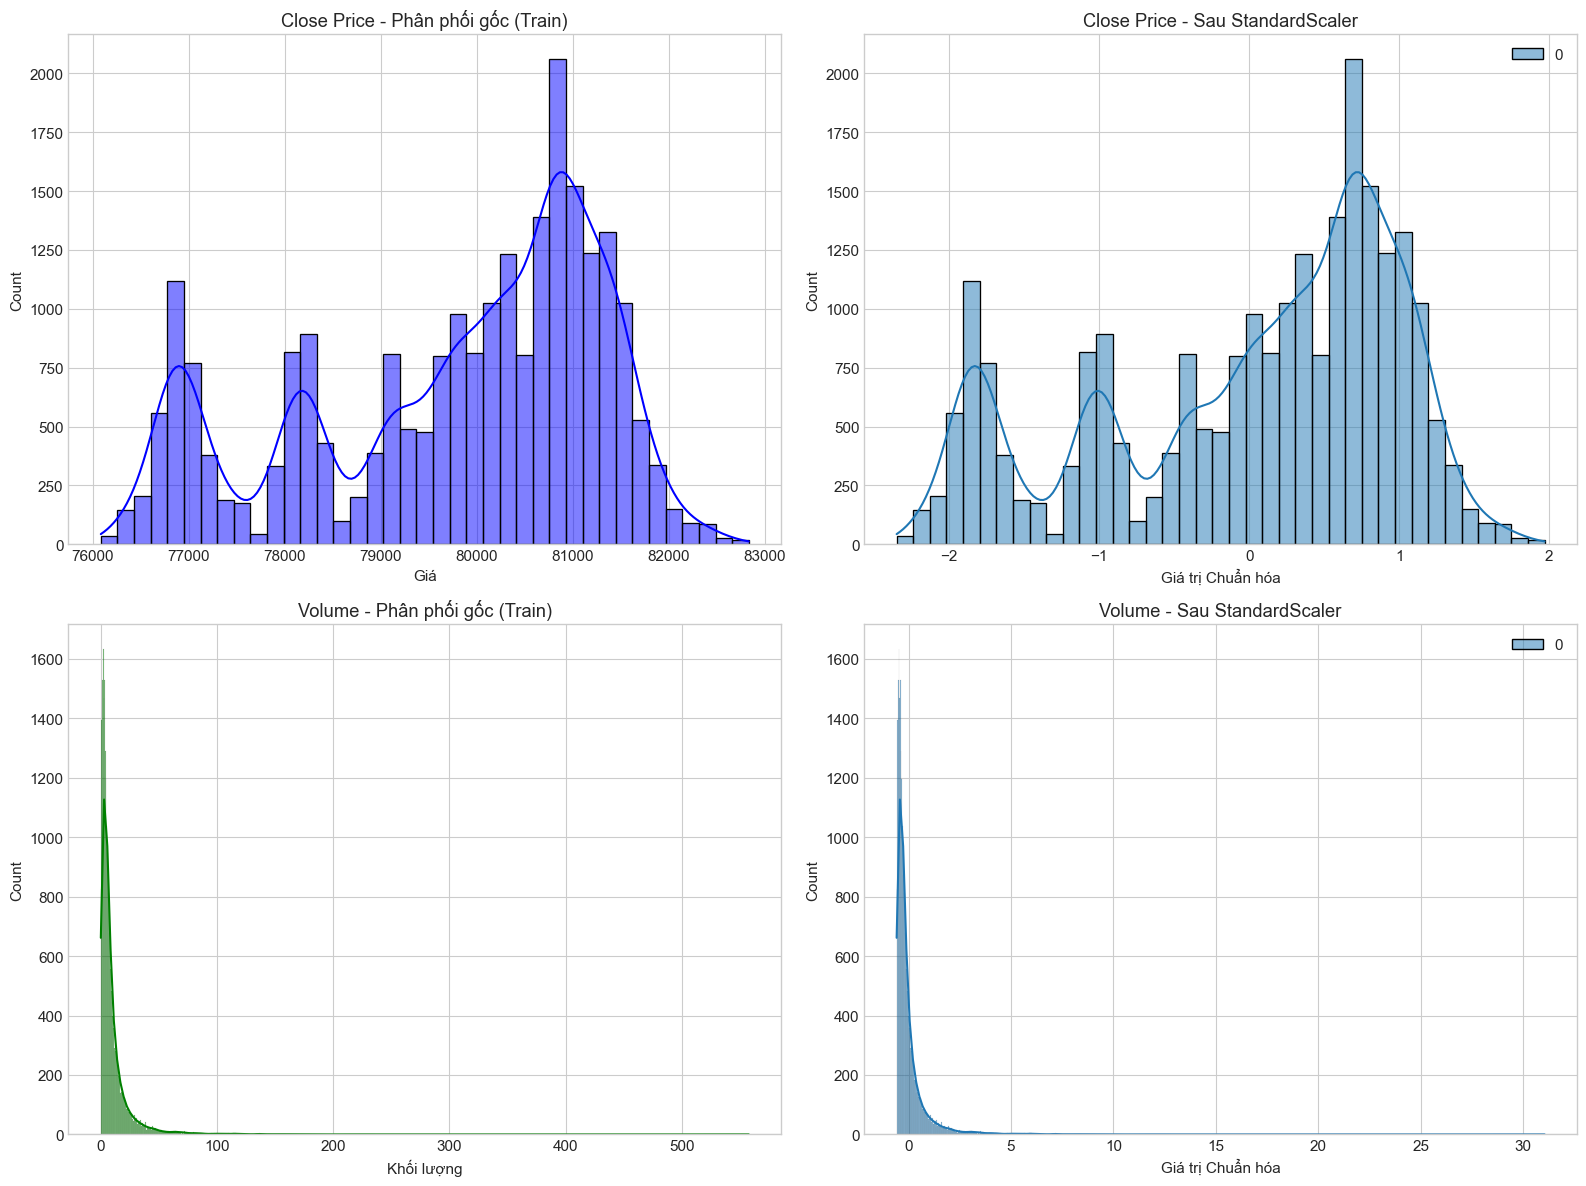

In [5]:
# Chia dữ liệu theo tỷ lệ 80% Train - 20% Test theo trình tự thời gian
split_idx = int(len(df_imputed) * 0.8)
train_df = df_imputed.iloc[:split_idx].copy()
test_df = df_imputed.iloc[split_idx:].copy()

print(f"Quy mô dữ liệu huấn luyện (Train): {train_df.shape}")
print(f"Quy mô dữ liệu kiểm thử (Test): {test_df.shape}")

# Chuẩn hóa dữ liệu
scaler_close = StandardScaler()
scaler_volume = StandardScaler()

# CHỈ fit trên tập Train
scaler_close.fit(train_df[['close']])
scaler_volume.fit(train_df[['volume']])

# Biến đổi trên cả hai tập
train_close_scaled = scaler_close.transform(train_df[['close']])
test_close_scaled = scaler_close.transform(test_df[['close']])

train_volume_scaled = scaler_volume.transform(train_df[['volume']])
test_volume_scaled = scaler_volume.transform(test_df[['volume']])

# Trực quan hóa phân phối trước và sau chuẩn hóa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Close trước chuẩn hóa
sns.histplot(train_df['close'], kde=True, color='blue', ax=axes[0, 0])
axes[0, 0].set_title('Close Price - Phân phối gốc (Train)')
axes[0, 0].set_xlabel('Giá')

# Close sau chuẩn hóa
sns.histplot(train_close_scaled, kde=True, color='darkblue', ax=axes[0, 1])
axes[0, 1].set_title('Close Price - Sau StandardScaler')
axes[0, 1].set_xlabel('Giá trị Chuẩn hóa')

# Volume trước chuẩn hóa
sns.histplot(train_df['volume'], kde=True, color='green', ax=axes[1, 0])
axes[1, 0].set_title('Volume - Phân phối gốc (Train)')
axes[1, 0].set_xlabel('Khối lượng')

# Volume sau chuẩn hóa
sns.histplot(train_volume_scaled, kde=True, color='darkgreen', ax=axes[1, 1])
axes[1, 1].set_title('Volume - Sau StandardScaler')
axes[1, 1].set_xlabel('Giá trị Chuẩn hóa')

plt.tight_layout()
plt.show()

## Bước 6: Phân tích Tương quan Pearson (Tránh Đa cộng tuyến hoàn toàn)

Chúng ta tính toán ma trận Pearson giữa 5 chiều dữ liệu OHLCV để xác nhận chúng không bị đa cộng tuyến hoàn toàn (Perfect Multicollinearity - hệ số tương quan bằng 1.0 tuyệt đối giữa các cột khác nhau), điều này có thể gây suy hao và mất ổn định cho các phép chiếu tuyến tính trong mô hình.

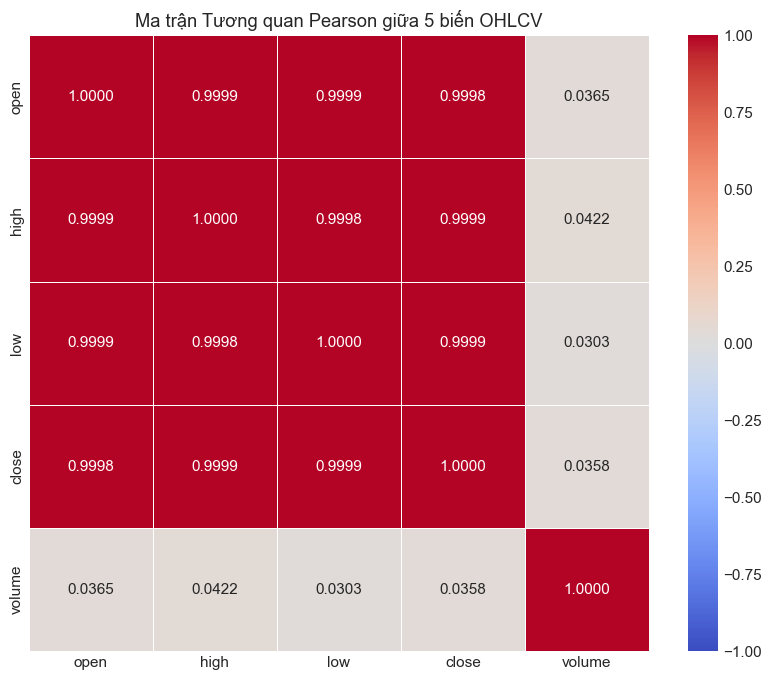

Kết quả kiểm định: Không có đa cộng tuyến hoàn toàn giữa các biến OHLCV. Dữ liệu sẵn sàng đưa vào các phép chiếu tuyến tính.


In [6]:
ohlcv_cols = ['open', 'high', 'low', 'close', 'volume']
corr_matrix = df_imputed[ohlcv_cols].corr(method='pearson')

# Vẽ heatmap tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Ma trận Tương quan Pearson giữa 5 biến OHLCV')
plt.show()

# Kiểm chứng xem có cặp biến nào tương quan bằng 1.0 tuyệt đối (trừ đường chéo)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
perfect_collinear = [column for column in upper_tri.columns if any(upper_tri[column] == 1.0)]

if perfect_collinear:
    print(f"Cảnh báo: Phát hiện đa cộng tuyến tuyệt đối tại các cột: {perfect_collinear}")
else:
    print("Kết quả kiểm định: Không có đa cộng tuyến hoàn toàn giữa các biến OHLCV. Dữ liệu sẵn sàng đưa vào các phép chiếu tuyến tính.")

## Bước 7: Trích xuất Đặc trưng Thời gian (Time Features)

Tạo các cột phụ đại diện cho bối cảnh thời gian để tích hợp làm dữ liệu bổ trợ `x_mark` và `y_mark` giúp cung cấp bối cảnh chu kỳ thời gian tốt nhất cho mô hình LLM.

In [7]:
df_features = df_imputed.copy()

# Trích xuất đặc trưng thời gian chuẩn hóa về phạm vi [-0.5, 0.5] để tối ưu hóa hội tụ mạng neural
df_features['day_of_week'] = df_features['timestamp'].dt.dayofweek / 6.0 - 0.5
df_features['hour_of_day'] = df_features['timestamp'].dt.hour / 23.0 - 0.5
df_features['minute_of_hour'] = df_features['timestamp'].dt.minute / 59.0 - 0.5

print("Tập dữ liệu sau khi tích hợp Đặc trưng Thời gian:")
df_features.head()

# Mô phỏng cấu trúc ma trận trước khi đưa vào Dataset PyTorch
x_arr = df_features[ohlcv_cols].values
x_mark_arr = df_features[['day_of_week', 'hour_of_day', 'minute_of_hour']].values

print(f"\nMô phỏng dữ liệu đưa vào PyTorch:")
print(f" - Khối dữ liệu chuỗi thời gian chính (OHLCV) shape: {x_arr.shape}")
print(f" - Khối thông tin bối cảnh thời gian (x_mark) shape: {x_mark_arr.shape}")

Tập dữ liệu sau khi tích hợp Đặc trưng Thời gian:

Mô phỏng dữ liệu đưa vào PyTorch:
 - Khối dữ liệu chuỗi thời gian chính (OHLCV) shape: (30000, 5)
 - Khối thông tin bối cảnh thời gian (x_mark) shape: (30000, 3)


## Bước 8: Trực quan hóa Biến động Chuỗi Thời gian (Line Charts)

Trong bước này, chúng ta sẽ thực hiện vẽ:
1. **Biểu đồ tổng hợp 5 biến**: Tích hợp cả 5 biến OHLCV trên cùng 1 biểu đồ. Vì khối lượng (`Volume`) có đơn vị đo lường và thang tỷ lệ hoàn toàn khác biệt so với các biến giá (`Open`, `High`, `Low`, `Close`), chúng ta sẽ áp dụng **trục kép Y song song** (Dual Y-Axis/twinx) để biểu diễn rõ nét giá trị của tất cả các biến.
2. **Phóng to một phân khúc (Zoom-in Section)**: Trích xuất một khoảng thời gian ngắn (ví dụ: 150 điểm dữ liệu liên tiếp) để hiển thị chi tiết biến động vi mô (intraday movement).
3. **Bi biểu đồ riêng biệt (Subplots)**: Vẽ các đồ thị đường riêng lẻ cho mỗi thuộc tính để dễ dàng phân tích xu hướng độc lập.

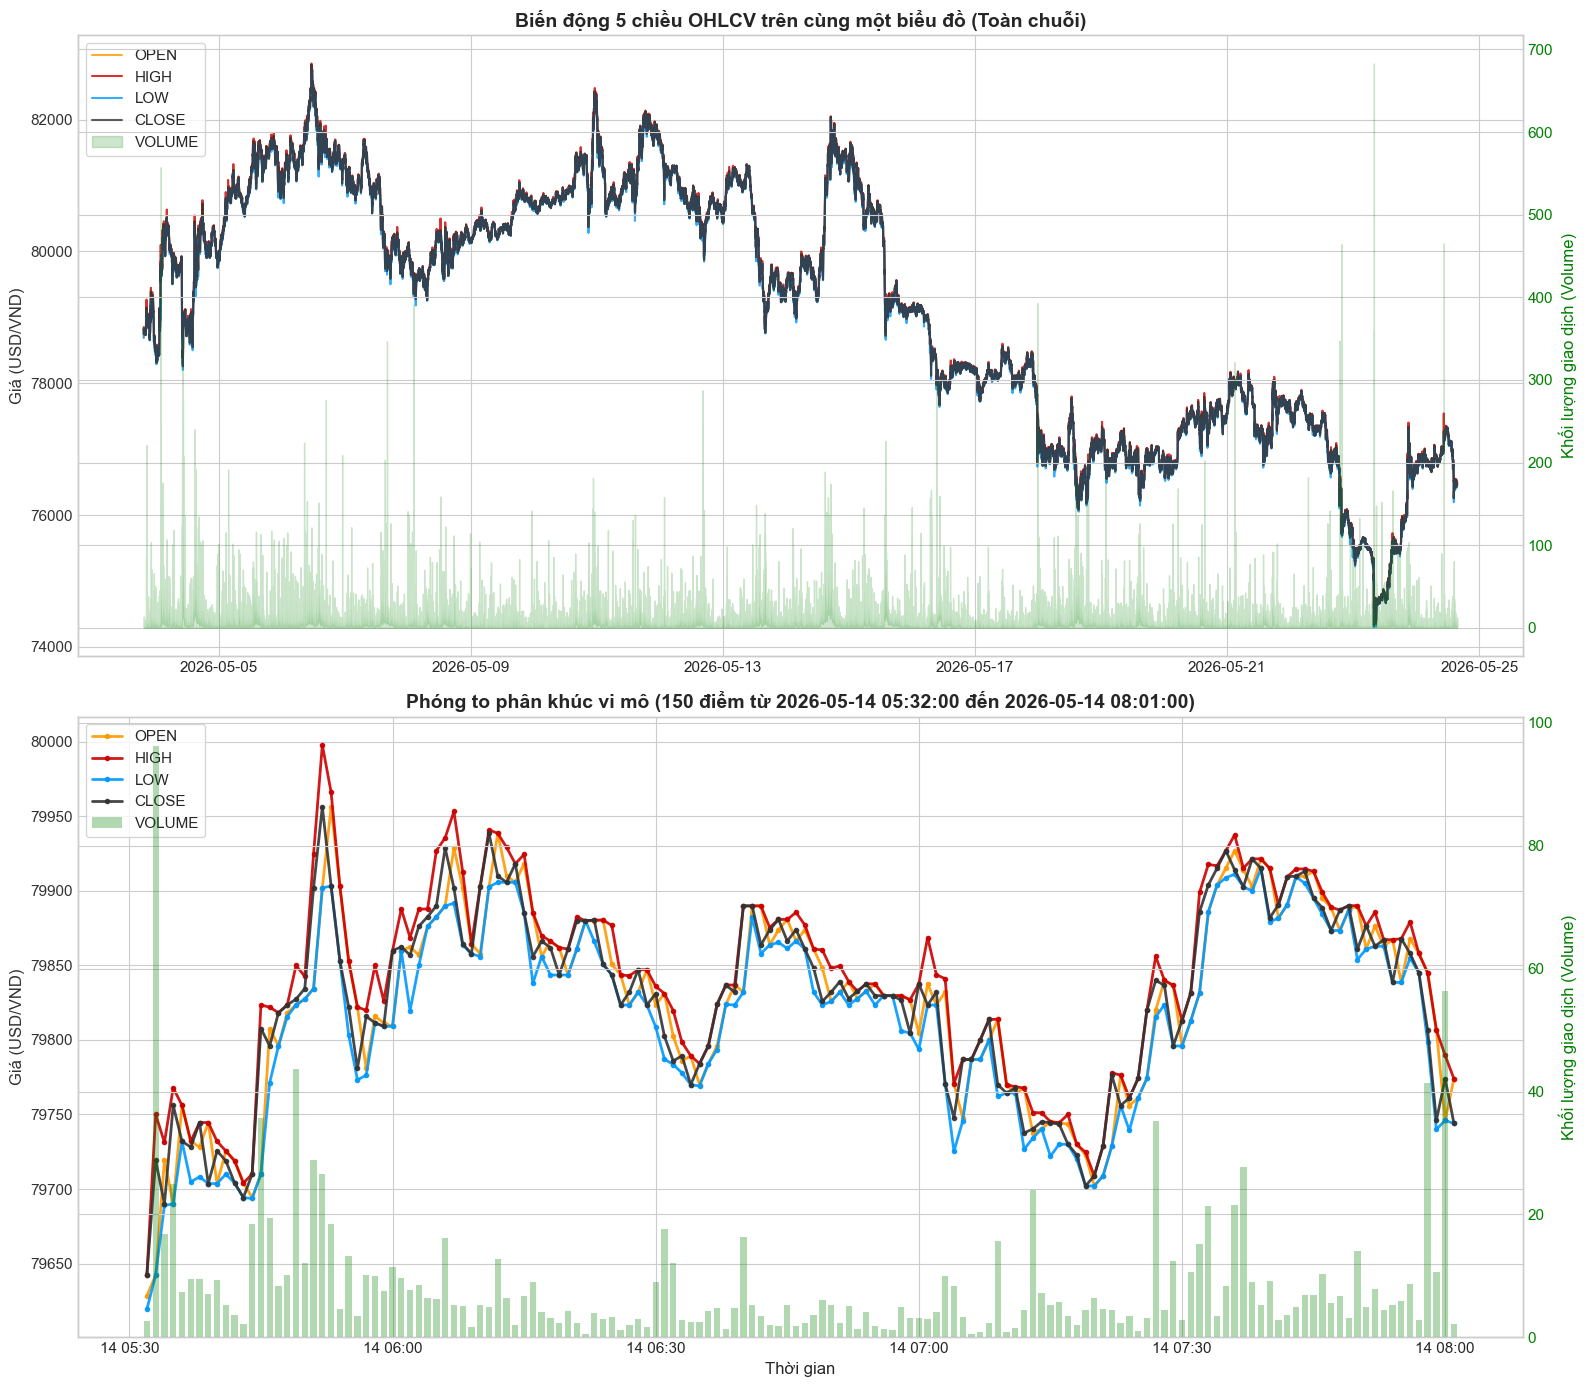

In [8]:
# ==========================================================================
# PHẦN 1: TỔNG HỢP CẢ 5 BIẾN VÀ PHÓNG TO PHÂN ĐOẠN
# ==========================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))

# --- ĐỒ THỊ 1: TỔNG HỢP TOÀN BỘ CHUỖI DỮ LIỆU ---
color_map = {'open': '#FF9900', 'high': '#CC0000', 'low': '#0099FF', 'close': '#333333'}

# Trục bên trái vẽ các biến giá (OHLC)
for price_col in ['open', 'high', 'low', 'close']:
    ax1.plot(df_imputed['timestamp'], df_imputed[price_col], label=price_col.upper(), 
             color=color_map[price_col], alpha=0.8, linewidth=1.5)
ax1.set_ylabel('Giá (USD/VND)', color='#333333', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#333333')
ax1.set_title('Biến động 5 chiều OHLCV trên cùng một biểu đồ (Toàn chuỗi)', fontsize=14, fontweight='bold')

# Trục bên phải vẽ biến khối lượng (Volume)
ax1_vol = ax1.twinx()
ax1_vol.fill_between(df_imputed['timestamp'], 0, df_imputed['volume'], label='VOLUME', 
                     color='green', alpha=0.2, step='post')
ax1_vol.set_ylabel('Khối lượng giao dịch (Volume)', color='green', fontsize=12)
ax1_vol.tick_params(axis='y', labelcolor='green')

# Hợp nhất label để tạo Legend chung
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_vol, labels_vol = ax1_vol.get_legend_handles_labels()
ax1.legend(lines_1 + lines_vol, labels_1 + labels_vol, loc='upper left', frameon=True)


# --- ĐỒ THỊ 2: PHÓNG TO PHÂN ĐOẠN VI MÔ (ZOOM-IN SECTION) ---
# Chọn 150 điểm dữ liệu ở giữa chuỗi thời gian để quan sát biến động vi mô
zoom_start = len(df_imputed) // 2
zoom_end = zoom_start + 150
df_zoom = df_imputed.iloc[zoom_start:zoom_end]

# Trục bên trái vẽ các biến giá (OHLC) phóng to
for price_col in ['open', 'high', 'low', 'close']:
    ax2.plot(df_zoom['timestamp'], df_zoom[price_col], label=price_col.upper(), 
             color=color_map[price_col], marker='.', alpha=0.9, linewidth=2)
ax2.set_ylabel('Giá (USD/VND)', color='#333333', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#333333')
ax2.set_title(f'Phóng to phân khúc vi mô (150 điểm từ {df_zoom["timestamp"].min()} đến {df_zoom["timestamp"].max()})', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Thời gian', fontsize=12)

# Trục bên phải vẽ khối lượng (Volume) phóng to
ax2_vol = ax2.twinx()
ax2_vol.bar(df_zoom['timestamp'], df_zoom['volume'], label='VOLUME', 
            color='green', alpha=0.3, width=0.0005) # thiết lập độ rộng cột nhỏ tránh đè lấp
ax2_vol.set_ylabel('Khối lượng giao dịch (Volume)', color='green', fontsize=12)
ax2_vol.tick_params(axis='y', labelcolor='green')

# Hợp nhất label cho đồ thị zoom
lines_2, labels_2 = ax2.get_legend_handles_labels()
lines_zoom_vol, labels_zoom_vol = ax2_vol.get_legend_handles_labels()
ax2.legend(lines_2 + lines_zoom_vol, labels_2 + labels_zoom_vol, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

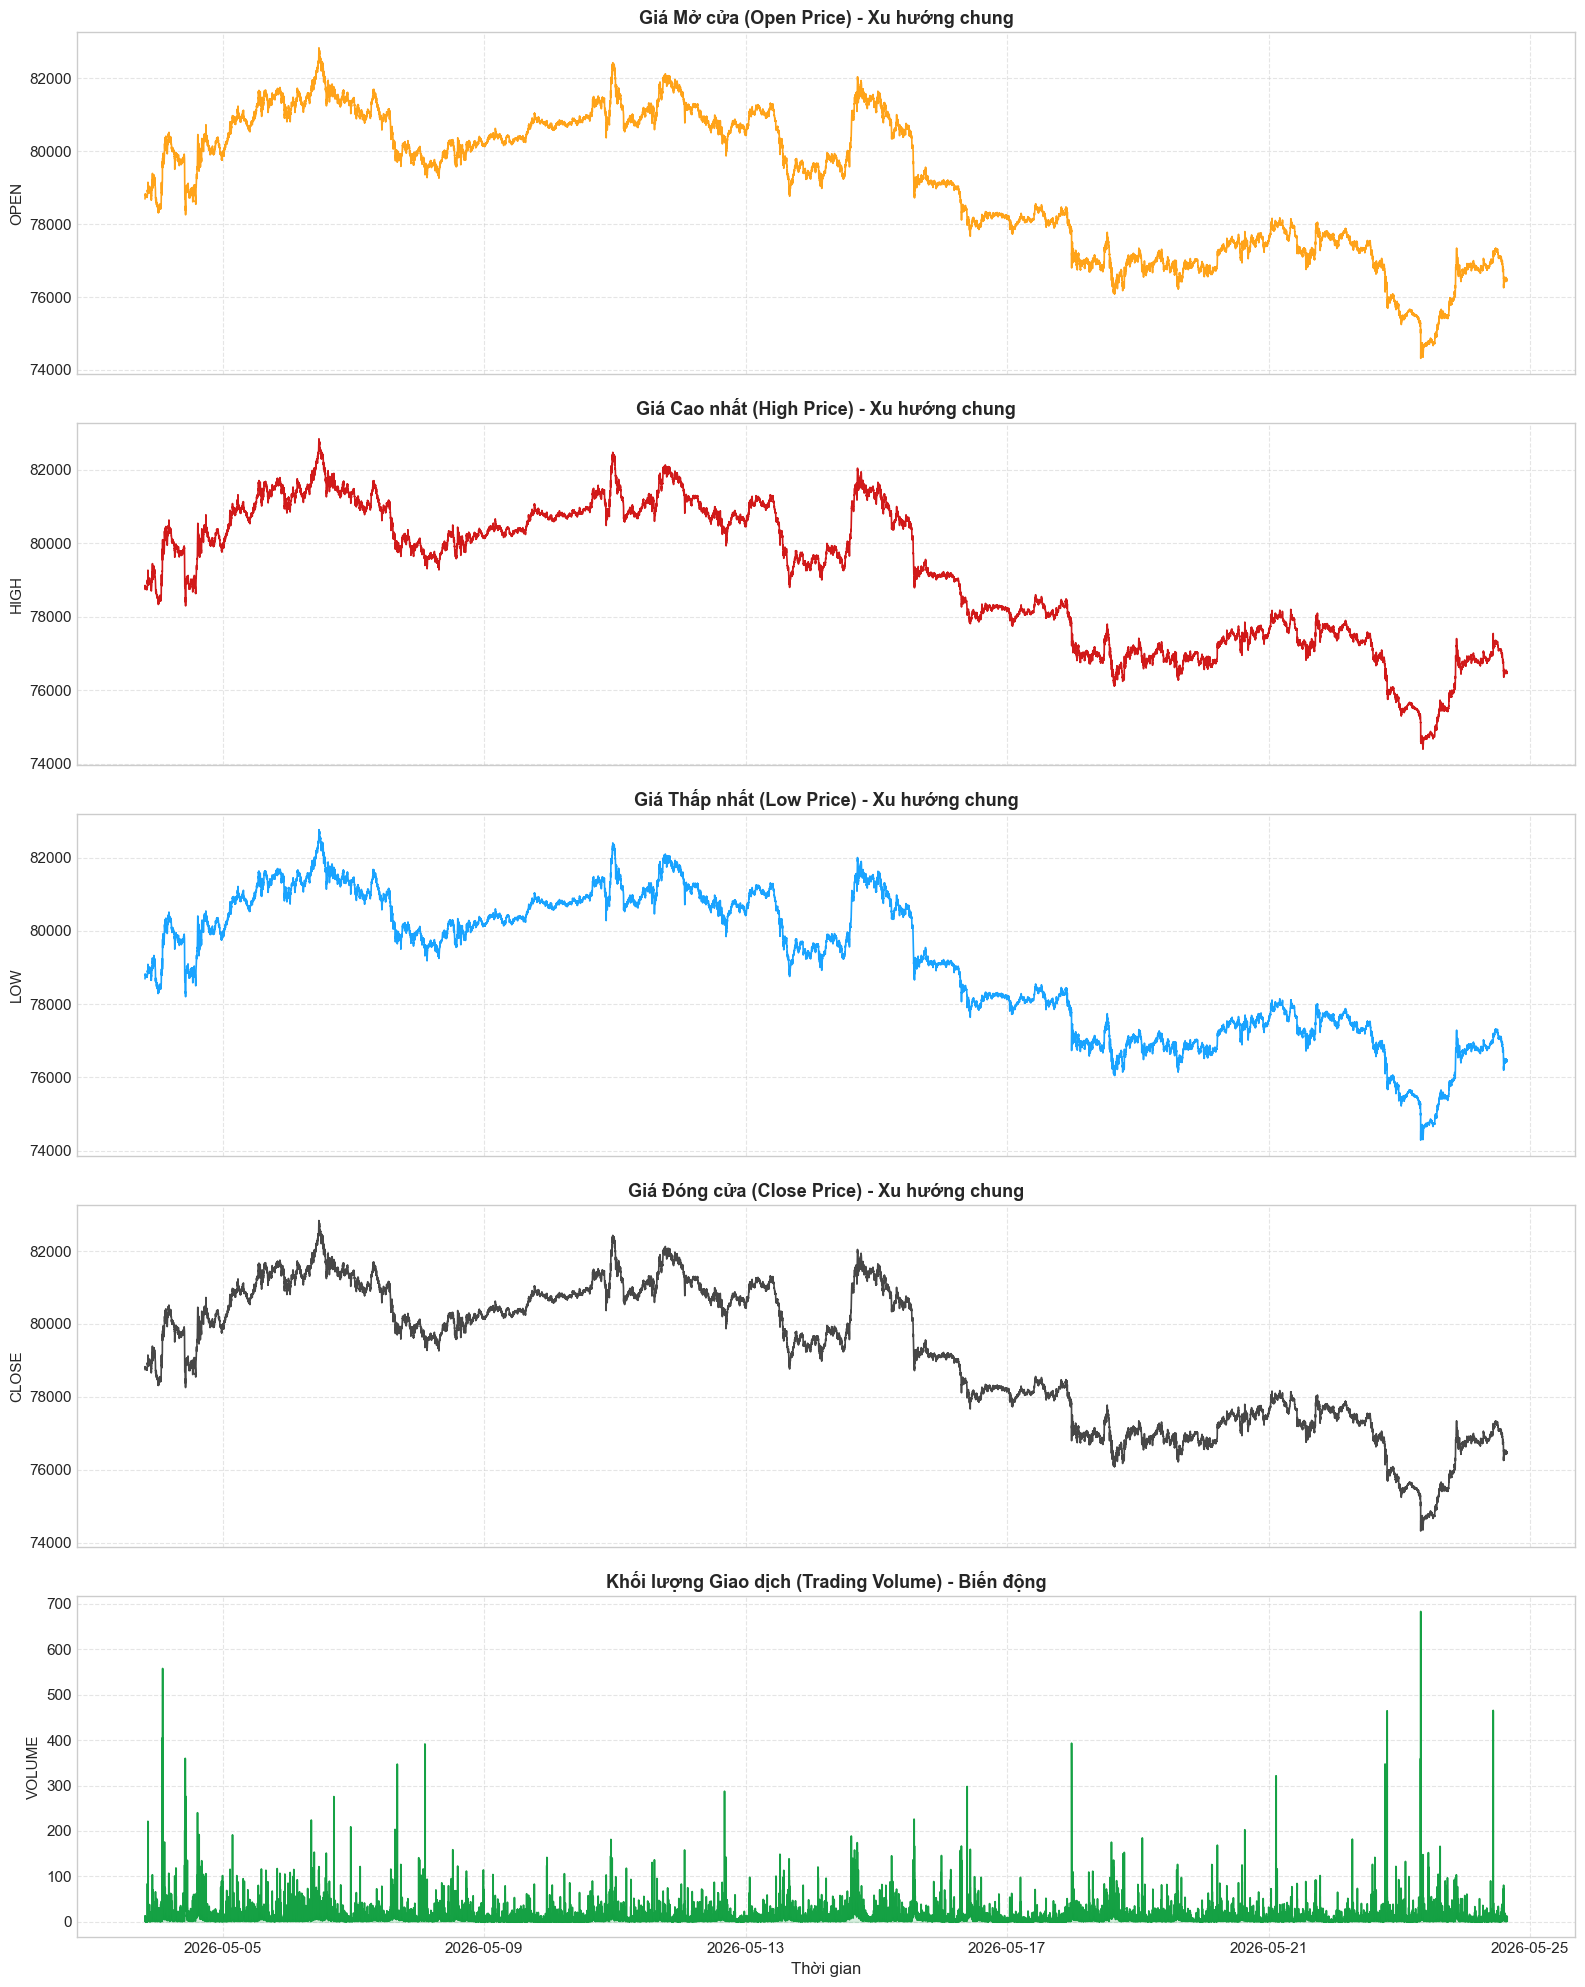

In [9]:
# ==========================================================================
# PHẦN 2: CÁC BIỂU ĐỒ ĐƯỜNG RIÊNG LẺ CHO TỪNG ĐẶC TRƯNG (SUBPLOTS)
# ==========================================================================

features_to_plot = ['open', 'high', 'low', 'close', 'volume']
feature_colors = ['#FF9900', '#CC0000', '#0099FF', '#333333', '#009933']
titles = [
    'Giá Mở cửa (Open Price) - Xu hướng chung',
    'Giá Cao nhất (High Price) - Xu hướng chung',
    'Giá Thấp nhất (Low Price) - Xu hướng chung',
    'Giá Đóng cửa (Close Price) - Xu hướng chung',
    'Khối lượng Giao dịch (Trading Volume) - Biến động'
]

fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=True)

for i, feature in enumerate(features_to_plot):
    axes[i].plot(df_imputed['timestamp'], df_imputed[feature], 
                 color=feature_colors[i], alpha=0.9, linewidth=1.2)
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_ylabel(feature.upper(), fontsize=11)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    
    # Thêm bóng mờ dưới đồ thị volume để tạo hiệu ứng chiều sâu trực quan đẹp mắt
    if feature == 'volume':
        axes[i].fill_between(df_imputed['timestamp'], 0, df_imputed['volume'], 
                             color=feature_colors[i], alpha=0.15)

axes[-1].set_xlabel('Thời gian', fontsize=12)
plt.tight_layout()
plt.show()